# 14 — Classification apprise du reliquat non classé (option 2)

**Constat de départ (notebook 13, Q1/Q8)** — les règles de `texte.classer()`
laissent 46 % des tickets du Système A en `non_classe` : ce n'est pas une
taxonomie incomplète, c'est le plafond de rappel d'une approche par
mots-clés (notebook 04, `texte.py` §"Limite assumée").

**Option retenue** — plutôt qu'ajouter des règles (rendement décroissant) ou
attendre un nouvel audit manuel, ce notebook exploite une ressource qui
existe déjà : les **950 tickets appariés entre A et B** (notebook 09) dont le
texte A est exploitable et dont le sous-motif B est **annoté à la main** —
le même jeu de référence de fait que le notebook 13 Q8 utilise pour mesurer
la fiabilité des règles. On l'utilise ici pour **entraîner** un classifieur
supervisé (TF-IDF + régression logistique) plutôt que pour seulement évaluer
les règles, puis on l'applique au reliquat `non_classe`.

**Biais à garder en tête (hérité du notebook 11 §4)** — ce jeu de référence
ne couvre que les tickets à la fois déposés en digital (Intercom) et
ressaisis manuellement côté B : probablement les cas les plus clairs à
qualifier. Un classifieur entraîné dessus généralise donc à un reliquat qui
peut être structurellement plus ambigu — c'est précisément pour ça que
l'évaluation ci-dessous (validation croisée) doit être lue comme un
**plafond optimiste**, pas une garantie sur le reliquat.

| | |
|---|---|
| **Entrée** | Système A classifié (notebook 13 setup), appariement A↔B (notebook 09), sous-motifs B (notebook 08) |
| **Sorties** | `resultats/tables/14_*.csv` + `resultats/figures/14_*.png` |


In [1]:
import sys
from pathlib import Path

RACINE = Path.cwd().parent
sys.path.insert(0, str(RACINE / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline

from reclamations import chargement, config, consolidation, systeme_b, texte, topics, viz

viz.appliquer_charte()
pd.set_option("display.width", 160)

# --- Système A : périmètre opérationnel complet + classification causale ---
df_a = chargement.typer(chargement.charger_brut())
tickets_a = chargement.perimetre_operationnel(df_a)
messages = chargement.charger_messages_ouverture()
tickets_a = tickets_a.copy()
tickets_a["texte"] = chargement.construire_texte_enrichi(tickets_a, messages)
tickets_a["a_texte"] = texte.a_texte_exploitable(tickets_a["texte"])
tickets_a["famille"] = texte.classer(tickets_a["texte"])
tickets_a["texte_masque"] = tickets_a["texte"].map(texte.masquer_identifiants)

# --- Système B : chargement complet, appariement (notebook 09) ---
tickets_b_brut = systeme_b.charger_tickets()
champs_b, valeurs_b = systeme_b.charger_champs_personnalises()
sous_motifs_b = systeme_b.sous_motifs(champs_b, valeurs_b)

cles_a = consolidation.cles_a(tickets_a)
cles_b = consolidation.cles_b(tickets_b_brut, champs_b, valeurs_b)
paires = consolidation.apparier(cles_a, cles_b)

print(f"Système A (période opérationnelle)         : {len(tickets_a):,}")
print(f"  dont non_classe par les règles (base texte): {(tickets_a['a_texte'] & (tickets_a['famille'] == texte.NON_CLASSE)).sum():,}")
print(f"Paires A<->B (notebook 09)                  : {len(paires):,}")

/home/gauss/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:261: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)
/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:261: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)


/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:261: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)
/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:261: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)
/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:261: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)


/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:261: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)


Système A (période opérationnelle)         : 18,056
  dont non_classe par les règles (base texte): 4,759
Paires A<->B (notebook 09)                  : 2,357


## 1. Jeu d'entraînement -- tickets appariés A↔B, texte A + sous-motif B

Même construction que le notebook 13 Q8 : un ticket A par paire, texte
exploitable, sous-motif B annoté.

In [2]:
jeu = paires[["ticket_id_a", "ticket_id_b"]].copy()
jeu["texte_masque"] = jeu["ticket_id_a"].map(tickets_a.set_index("id")["texte_masque"])
jeu["a_texte"] = jeu["ticket_id_a"].map(tickets_a.set_index("id")["a_texte"])
jeu = jeu.merge(sous_motifs_b[["sous_motif"]], left_on="ticket_id_b", right_index=True, how="inner")
jeu = jeu.drop_duplicates(["ticket_id_a", "ticket_id_b"])
jeu = jeu[jeu["a_texte"] == True]
jeu = jeu.drop_duplicates("ticket_id_a")

effectifs_classe = jeu["sous_motif"].value_counts()
print(f"Jeu de référence de fait : {len(jeu):,} tickets, {jeu['sous_motif'].nunique()} sous-motifs distincts")
print(effectifs_classe)

Jeu de référence de fait : 950 tickets, 13 sous-motifs distincts
sous_motif
Échec Cash-In                   332
Bénéficiaire erroné             299
Échec Wallet-to-Other-Wallet    221
Échec Wallet-to-Wallet           27
Fond non perçu                   22
Échec Cash-Out                   21
Opérations GAB AFB                8
Opérations GAB                    6
Autre                             4
Échec MAC Bank-to-Wallet          3
Opération Contestée               3
Échec Achat Air-Time              3
Versement GAB                     1
Name: count, dtype: int64


## 2. Filtrage des classes trop rares

Une validation croisée stratifiée exige plusieurs exemples par classe. Sous
`SEUIL_MIN_CLASSE`, un sous-motif reste dans la sortie du classifieur mais
ne peut pas être évalué de façon fiable ni prédit de façon robuste (le
modèle n'aurait vu que quelques exemples). Ces classes sont **exclues de
l'entraînement**, pas masquées : elles sont listées explicitement, même
logique de transparence que la ligne `non_classe` conservée dans
`texte.couverture()` -- on ne cache pas ce qu'on ne sait pas mesurer.

In [3]:
SEUIL_MIN_CLASSE = 20

classes_retenues = effectifs_classe[effectifs_classe >= SEUIL_MIN_CLASSE].index
classes_exclues = effectifs_classe[effectifs_classe < SEUIL_MIN_CLASSE]

entrainement = jeu[jeu["sous_motif"].isin(classes_retenues)].copy()

print(f"Classes retenues ({len(classes_retenues)}) -- {entrainement.shape[0]} tickets d'entraînement :")
print(effectifs_classe.loc[classes_retenues])
print()
print(f"Classes exclues (< {SEUIL_MIN_CLASSE} tickets, {classes_exclues.sum()} tickets au total, non couvertes par le classifieur) :")
print(classes_exclues)

Classes retenues (6) -- 922 tickets d'entraînement :
sous_motif
Échec Cash-In                   332
Bénéficiaire erroné             299
Échec Wallet-to-Other-Wallet    221
Échec Wallet-to-Wallet           27
Fond non perçu                   22
Échec Cash-Out                   21
Name: count, dtype: int64

Classes exclues (< 20 tickets, 28 tickets au total, non couvertes par le classifieur) :
sous_motif
Opérations GAB AFB          8
Opérations GAB              6
Autre                       4
Échec MAC Bank-to-Wallet    3
Opération Contestée         3
Échec Achat Air-Time        3
Versement GAB               1
Name: count, dtype: int64


## 3. Fiabilité mesurée par validation croisée (5 blocs stratifiés)

Même principe que la mesure de fiabilité des règles au notebook 13 Q8 :
précision / rappel / F1 par classe, mais ici sur les prédictions du
classifieur plutôt que sur les règles. TF-IDF (mêmes mots vides bilingues
que `topics.py`, notebook 07) + régression logistique, poids de classes
équilibrés pour compenser le déséquilibre (332 contre 21 tickets selon la
classe).

In [4]:
GRAINE = 42

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(min_df=2, max_df=0.6, ngram_range=(1, 2), stop_words=list(topics.MOTS_VIDES))),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=GRAINE)),
])

X = entrainement["texte_masque"]
y = entrainement["sous_motif"]

decoupage = StratifiedKFold(n_splits=5, shuffle=True, random_state=GRAINE)
y_pred = cross_val_predict(pipeline, X, y, cv=decoupage)

rapport = classification_report(y, y_pred, output_dict=True, zero_division=0)
resultat_14 = (
    pd.DataFrame(rapport).T
    .drop(index=["accuracy"], errors="ignore")
    .loc[lambda d: d.index.isin(classes_retenues)]
    .rename(columns={"support": "n"})
    .assign(n=lambda d: d["n"].astype(int))
    .sort_values("n", ascending=False)
)
exactitude_globale = rapport["accuracy"]
chargement.sauver_table(resultat_14, "14_classifieur_performance_cv")

print(f"Exactitude globale (validation croisée, {len(classes_retenues)} classes) : {exactitude_globale:.1%}")
resultat_14[["precision", "recall", "f1-score", "n"]]

  -> resultats/tables/14_classifieur_performance_cv.csv
Exactitude globale (validation croisée, 6 classes) : 75.7%


,precision,recall,f1-score,n
Échec Cash-In,0.833333,0.798193,0.815385,332
Bénéficiaire erroné,0.880259,0.909699,0.894737,299
Échec Wallet-to-Other-Wallet,0.608333,0.660633,0.633406,221
Échec Wallet-to-Wallet,0.233333,0.259259,0.245614,27
Fond non perçu,0.437500,0.318182,0.368421,22
Échec Cash-Out,0.111111,0.047619,0.066667,21


  -> resultats/figures/14_classifieur_performance_cv.png


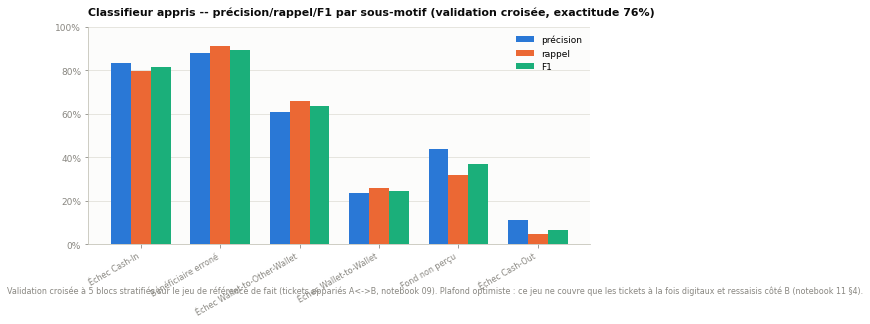

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(resultat_14))
largeur = 0.25
ax.bar([i - largeur for i in x], resultat_14["precision"], width=largeur, label="précision", color=viz.SERIES[0])
ax.bar(list(x), resultat_14["recall"], width=largeur, label="rappel", color=viz.SERIES[1])
ax.bar([i + largeur for i in x], resultat_14["f1-score"], width=largeur, label="F1", color=viz.SERIES[2])
ax.set_xticks(list(x))
ax.set_xticklabels(resultat_14.index, rotation=30, ha="right", fontsize=8)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1, decimals=0))
ax.set_title(f"Classifieur appris -- précision/rappel/F1 par sous-motif (validation croisée, exactitude {exactitude_globale:.0%})")
ax.legend(frameon=False, fontsize=9)
ax.grid(axis="x", visible=False)
viz.annoter_source(
    fig,
    "Validation croisée à 5 blocs stratifiés sur le jeu de référence de fait (tickets appariés A<->B, notebook 09). "
    "Plafond optimiste : ce jeu ne couvre que les tickets à la fois digitaux et ressaisis côté B (notebook 11 §4).",
)
viz.sauver(fig, "14_classifieur_performance_cv")
plt.show()

## 4. Application au reliquat `non_classe`

Le pipeline est ré-entraîné sur l'intégralité des tickets d'entraînement
retenus, puis appliqué aux tickets que les règles n'ont pas su classer. Une
prédiction n'est retenue que si la probabilité maximale du modèle dépasse
`SEUIL_CONFIANCE` -- en dessous, le ticket reste explicitement
`incertain_classifieur` plutôt que de recevoir une étiquette peu fiable
déguisée en certitude.

In [6]:
SEUIL_CONFIANCE = 0.45

pipeline.fit(X, y)

reliquat = tickets_a[tickets_a["a_texte"] & (tickets_a["famille"] == texte.NON_CLASSE)].copy()
proba = pipeline.predict_proba(reliquat["texte_masque"])
classes_modele = pipeline.named_steps["clf"].classes_

reliquat["sous_motif_predit"] = classes_modele[np.argmax(proba, axis=1)]
reliquat["confiance"] = proba.max(axis=1)
reliquat.loc[reliquat["confiance"] < SEUIL_CONFIANCE, "sous_motif_predit"] = "incertain_classifieur"

distribution = reliquat["sous_motif_predit"].value_counts().rename("effectif").to_frame()
distribution["pct"] = (distribution["effectif"] / len(reliquat) * 100).round(1)
chargement.sauver_table(distribution, "14_reliquat_sous_motifs_predits")

n_total_a = len(tickets_a[tickets_a["a_texte"]])
n_non_classe_avant = len(reliquat)
n_incertain = (reliquat["sous_motif_predit"] == "incertain_classifieur").sum()
n_requalifie = n_non_classe_avant - n_incertain

print(f"Reliquat non_classe (règles)                         : {n_non_classe_avant:,} / {n_total_a:,} ({n_non_classe_avant / n_total_a:.1%})")
print(f"  dont requalifié par le classifieur (confiance >= {SEUIL_CONFIANCE:.0%}) : {n_requalifie:,} ({n_requalifie / n_non_classe_avant:.1%} du reliquat)")
print(f"  dont resté incertain (confiance < {SEUIL_CONFIANCE:.0%})               : {n_incertain:,} ({n_incertain / n_non_classe_avant:.1%} du reliquat)")
print()
print(f"Non classé, après règles + classifieur : {n_incertain / n_total_a:.1%} (contre {n_non_classe_avant / n_total_a:.1%} avant)")
print()
distribution

  -> resultats/tables/14_reliquat_sous_motifs_predits.csv
Reliquat non_classe (règles)                         : 4,759 / 10,354 (46.0%)
  dont requalifié par le classifieur (confiance >= 45%) : 2,038 (42.8% du reliquat)
  dont resté incertain (confiance < 45%)               : 2,721 (57.2% du reliquat)

Non classé, après règles + classifieur : 26.3% (contre 46.0% avant)



,effectif,pct
sous_motif_predit,,
incertain_classifieur,2721,57.2
Échec Cash-In,1641,34.5
Bénéficiaire erroné,280,5.9
Échec Wallet-to-Other-Wallet,71,1.5
Échec Cash-Out,23,0.5
Échec Wallet-to-Wallet,19,0.4
Fond non perçu,4,0.1


  -> resultats/figures/14_reliquat_sous_motifs_predits.png


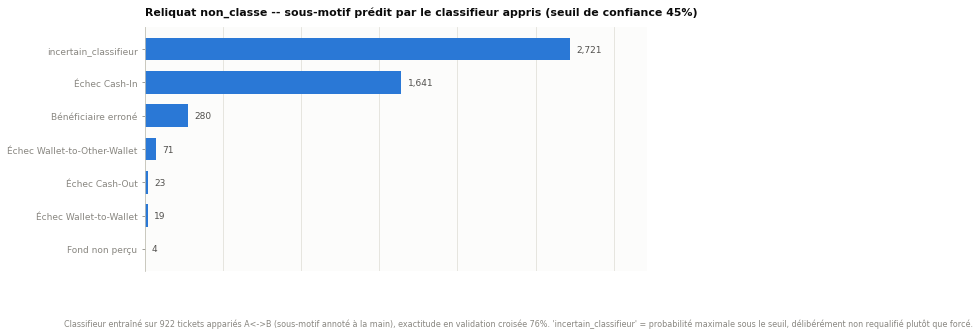

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
viz.barres_horizontales(
    distribution["effectif"],
    f"Reliquat non_classe -- sous-motif prédit par le classifieur appris (seuil de confiance {SEUIL_CONFIANCE:.0%})",
    ax=ax,
)
viz.annoter_source(
    fig,
    f"Classifieur entraîné sur {len(entrainement):,} tickets appariés A<->B (sous-motif annoté à la main), "
    f"exactitude en validation croisée {exactitude_globale:.0%}. 'incertain_classifieur' = probabilité maximale sous le seuil, "
    "délibérément non requalifié plutôt que forcé.",
)
viz.sauver(fig, "14_reliquat_sous_motifs_predits")
plt.show()

## 5. Ce que cette classification apprise établit -- et ce qu'elle n'établit pas

**Ce qui est solide :**
- Le jeu d'entraînement est une annotation humaine indépendante (Système B),
  pas une auto-évaluation des règles.
- La validation croisée donne une mesure honnête de la fiabilité *sur ce
  jeu* -- exactitude ci-dessus, détaillée par classe dans
  `14_classifieur_performance_cv.csv`.
- Le seuil de confiance évite de forcer une étiquette peu fiable : le
  reliquat non couvert reste visible (`incertain_classifieur`), pas caché.

**Ce qui reste une extrapolation, pas une mesure :**
- Le jeu d'entraînement est biaisé vers les cas les plus clairs à qualifier
  (notebook 11 §4) -- l'exactitude sur le reliquat réel est probablement
  **inférieure** à celle mesurée en validation croisée.
- Seuls 6 sous-motifs ont assez d'exemples pour être appris
  (`SEUIL_MIN_CLASSE` = 20) ; un ticket du reliquat dont le vrai motif est
  l'un des 7 sous-motifs rares sera nécessairement mal classé ou classé
  `incertain_classifieur`.
- Cette classification n'a pas été relue par un humain -- avant tout usage
  décisionnel (ex. priorisation d'un service), un échantillon des
  prédictions à haute confiance devrait être audité, même logique que
  l'audit manuel du notebook 04.

**Prochaine étape si cette voie est retenue** -- élargir le jeu de
référence : chaque nouvel export enrichit mécaniquement le nombre de paires
A↔B (notebook 09), donc le nombre d'exemples disponibles pour entraîner et
valider ce classifieur, sans travail de ré-annotation supplémentaire.